# Visual laboratory: from finite gaps to continuous change

We follow one function throughout the laboratory:

$$
f(x)=x^2.
$$

The objective is to see three connected operations: measure change across a finite gap, remove that measuring scale through a limit, and accumulate the resulting local law through an integral.

## Secant rulers approaching the tangent

At $x=3$, the finite-difference slope is exact for every nonzero gap $h$:

$$
D_hf(3)=\frac{f(3+h)-f(3)}{h}=6+h.
$$

Each panel uses a smaller ruler. The final panel shows the limiting tangent with slope $f'(3)=6$.

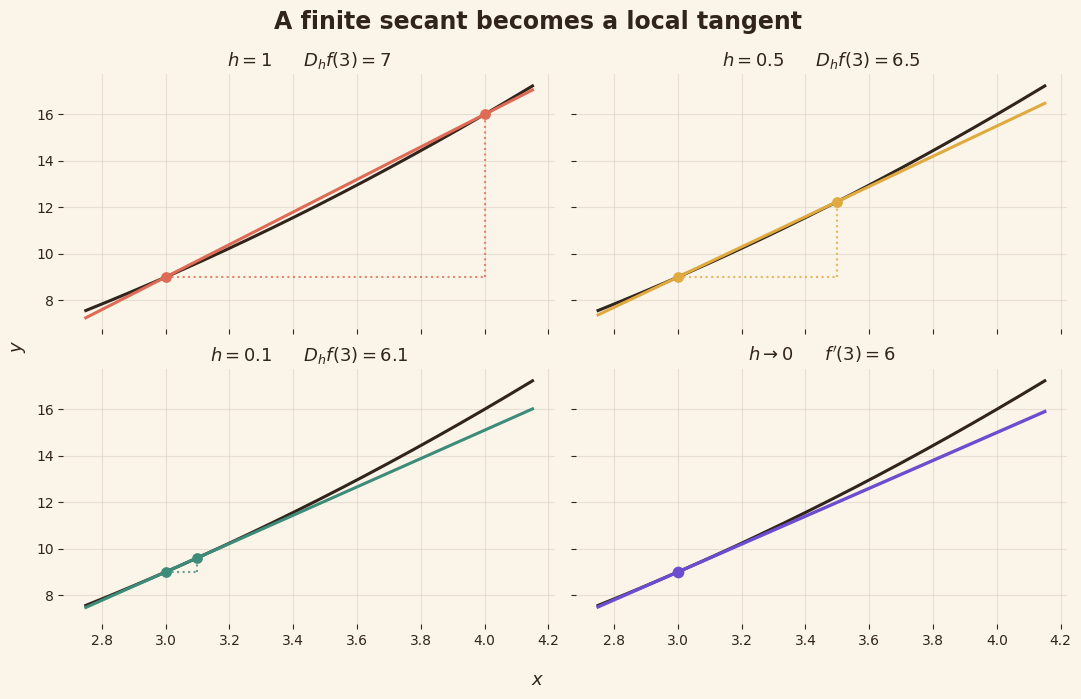

In [1]:
import numpy as np
import matplotlib.pyplot as plt

ink = '#30241d'
paper = '#fbf4e8'
purple = '#6c4ccf'
coral = '#dd6b55'
gold = '#dfaa3f'
teal = '#3d8c7a'
grid = '#d9cfc1'

xs = np.linspace(2.75, 4.15, 400)
fig, axes = plt.subplots(2, 2, figsize=(11, 7), facecolor=paper, sharex=True, sharey=True)
cases = [(1.0, coral), (0.5, gold), (0.1, teal), (0.0, purple)]
for ax, (h, color) in zip(axes.flat, cases):
    ax.set_facecolor(paper)
    ax.plot(xs, xs**2, color=ink, linewidth=2.2, label=r'$f(x)=x^2$')
    x0, y0 = 3.0, 9.0
    if h > 0:
        slope = 6 + h
        x1, y1 = x0 + h, (x0 + h)**2
        line = y0 + slope * (xs - x0)
        ax.plot(xs, line, color=color, linewidth=2.2)
        ax.scatter([x0, x1], [y0, y1], color=color, s=45, zorder=4)
        ax.plot([x0, x1], [y0, y0], color=color, linestyle=':', alpha=.8)
        ax.plot([x1, x1], [y0, y1], color=color, linestyle=':', alpha=.8)
        ax.set_title(rf'$h={h:g}$     $D_hf(3)={slope:g}$', color=ink, fontsize=13, weight='bold')
    else:
        line = y0 + 6 * (xs - x0)
        ax.plot(xs, line, color=color, linewidth=2.4)
        ax.scatter([x0], [y0], color=color, s=55, zorder=4)
        ax.set_title(r'$h\to0$     $f^{\prime}(3)=6$', color=ink, fontsize=13, weight='bold')
    ax.grid(color=grid, alpha=.55, linewidth=.8)
    ax.tick_params(colors=ink)
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.supxlabel('$x$', color=ink, fontsize=13)
fig.supylabel('$y$', color=ink, fontsize=13)
fig.suptitle('A finite secant becomes a local tangent', color=ink, fontsize=17, weight='bold')
fig.tight_layout()
plt.show()

## The scale-dependent family has a limit

There is no smallest positive $h$. Instead, all finite measurements belong to the family $D_hf(3)=6+h$, and the limit identifies their stable destination:

$$
\lim_{h\to0}D_hf(3)=6.
$$

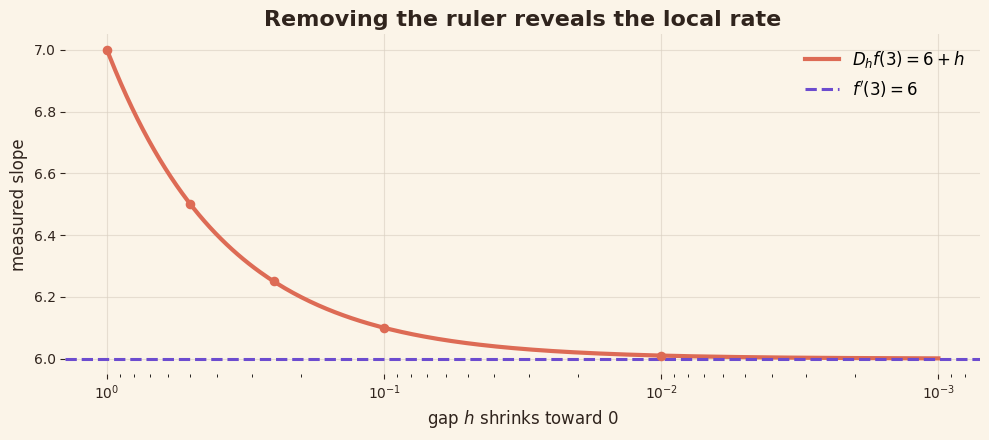

In [2]:
hs = np.geomspace(1e-3, 1, 300)
slopes = 6 + hs
fig, ax = plt.subplots(figsize=(10, 4.5), facecolor=paper)
ax.set_facecolor(paper)
ax.plot(hs, slopes, color=coral, linewidth=3, label=r'$D_hf(3)=6+h$')
ax.axhline(6, color=purple, linewidth=2.2, linestyle='--', label=r'$f^{\prime}(3)=6$')
for h in [1, .5, .25, .1, .01]:
    ax.scatter([h], [6+h], color=coral, s=35, zorder=3)
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel(r'gap $h$ shrinks toward $0$', color=ink, fontsize=12)
ax.set_ylabel('measured slope', color=ink, fontsize=12)
ax.set_title('Removing the ruler reveals the local rate', color=ink, fontsize=16, weight='bold')
ax.grid(color=grid, alpha=.6)
ax.legend(frameon=False, fontsize=12)
ax.tick_params(colors=ink)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
plt.show()

## Accumulating the local law

The derivative $f'(x)=2x$ is a rate, so each local contribution has the form $f'(x_k)\,\Delta x$. On $[3,4]$, left-endpoint sums satisfy

$$
S_n=\sum_{k=0}^{n-1} f'(x_k)\,\Delta x=7-\frac{1}{n}.
$$

Refining the partition makes the rectangles converge to the area under $2x$, which is the exact change $f(4)-f(3)=7$.

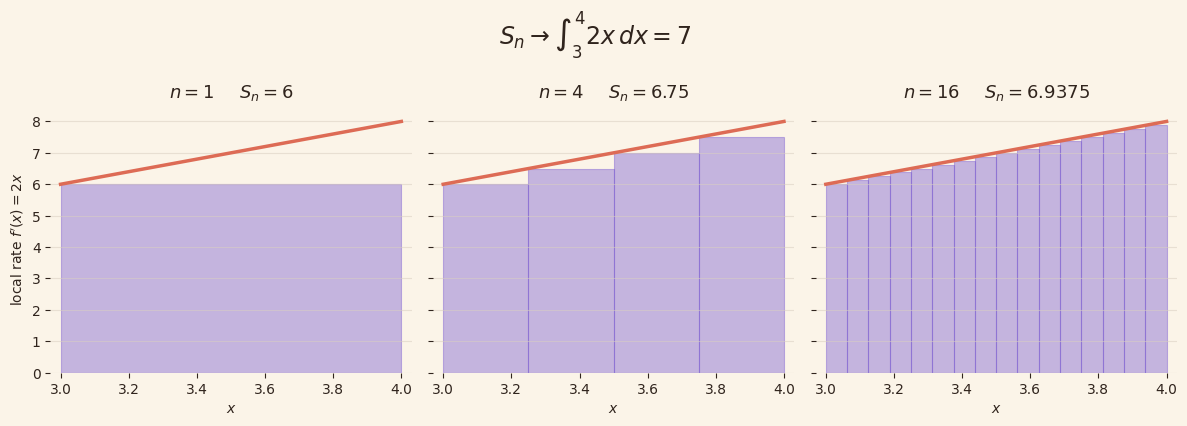

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.3), facecolor=paper, sharey=True)
curve_x = np.linspace(3, 4, 300)
for ax, n in zip(axes, [1, 4, 16]):
    ax.set_facecolor(paper)
    dx = 1 / n
    left = 3 + np.arange(n) * dx
    heights = 2 * left
    ax.bar(left, heights, width=dx, align='edge', color=purple, alpha=.38, edgecolor=purple, linewidth=.8)
    ax.plot(curve_x, 2*curve_x, color=coral, linewidth=2.5)
    estimate = 7 - 1/n
    ax.set_title(rf'$n={n}$    $S_n={estimate:g}$', color=ink, fontsize=13, weight='bold')
    ax.set_xlabel('$x$', color=ink)
    ax.set_xlim(2.97, 4.03)
    ax.set_ylim(0, 8.5)
    ax.grid(axis='y', color=grid, alpha=.55)
    ax.tick_params(colors=ink)
    for spine in ax.spines.values():
        spine.set_visible(False)
axes[0].set_ylabel(r'local rate $f^{\prime}(x)=2x$', color=ink)
fig.suptitle(r'$S_n\to\int_3^4 2x\,dx=7$', color=ink, fontsize=17, weight='bold')
fig.tight_layout()
plt.show()

## One continuous chain

The complete relation is:

$$
\frac{f(x+h)-f(x)}{h}
\xrightarrow[h\to0]{}
f'(x)
\xrightarrow{\text{accumulate on }[a,b]}
\int_a^b f'(x)\,dx
=f(b)-f(a).
$$

Finite differences measure a selected scale. The derivative identifies the local law that survives removal of that scale. The integral composes those local contributions into global change.